# Task Info

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
!pip install mysql-connector-python

# Code Work

In [73]:
import mysql.connector

In [74]:
connection = mysql.connector.connect(
    host="localhost",
    user="air_user",
    password="root",
    database="air_quality_db"
)

print("MySQL Connected Successfully!")

ProgrammingError: 1045 (28000): Access denied for user 'air_user'@'localhost' (using password: YES)

In [15]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra Pradesh,Kakinada,"Rama Rao Peta, Kakinada - APPCB",25-08-2026 17.00,16.962488,82.229513,NO2,27.0,51.0,39.0
1,India,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",25-08-2026 17.00,15.834110,78.028546,PM10,28.0,47.0,38.0
2,India,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",25-08-2026 17.00,15.834110,78.028546,NH3,6.0,6.0,6.0
3,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",25-08-2026 17.00,16.186555,81.132190,PM10,52.0,64.0,55.0
4,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",25-08-2026 17.00,16.186555,81.132190,NH3,2.0,4.0,4.0


In [16]:
df.tail()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
3544,India,West Bengal,Kolkata,"Victoria, Kolkata - WBPCB",25-08-2026 17.00,22.544808,88.340369,NH3,6.0,7.0,6.0
3545,India,West Bengal,Siliguri,"Ward-32 Bapupara, Siliguri - WBPCB",25-08-2026 17.00,26.687923,88.415250,PM2.5,14.0,29.0,20.0
3546,India,West Bengal,Siliguri,"Ward-32 Bapupara, Siliguri - WBPCB",25-08-2026 17.00,26.687923,88.415250,PM10,23.0,37.0,28.0
3547,India,West Bengal,Siliguri,"Ward-32 Bapupara, Siliguri - WBPCB",25-08-2026 17.00,26.687923,88.415250,NO2,112.0,127.0,118.0
3548,India,West Bengal,Siliguri,"Ward-32 Bapupara, Siliguri - WBPCB",25-08-2026 17.00,26.687923,88.415250,CO,9.0,35.0,18.0


In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3549
Columns: 11


In [18]:
df.columns

Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg'],
      dtype='object')

In [19]:
df.dtypes

country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3549 entries, 0 to 3548
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3549 non-null   object 
 1   state          3549 non-null   object 
 2   city           3549 non-null   object 
 3   station        3549 non-null   object 
 4   last_update    3549 non-null   object 
 5   latitude       3549 non-null   float64
 6   longitude      3549 non-null   float64
 7   pollutant_id   3549 non-null   object 
 8   pollutant_min  3219 non-null   float64
 9   pollutant_max  3219 non-null   float64
 10  pollutant_avg  3219 non-null   float64
dtypes: float64(5), object(6)
memory usage: 305.1+ KB


In [21]:
# Replace all missing values with 0
df = df.fillna(0)

# Check missing values
print(df.isnull().sum())

country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64


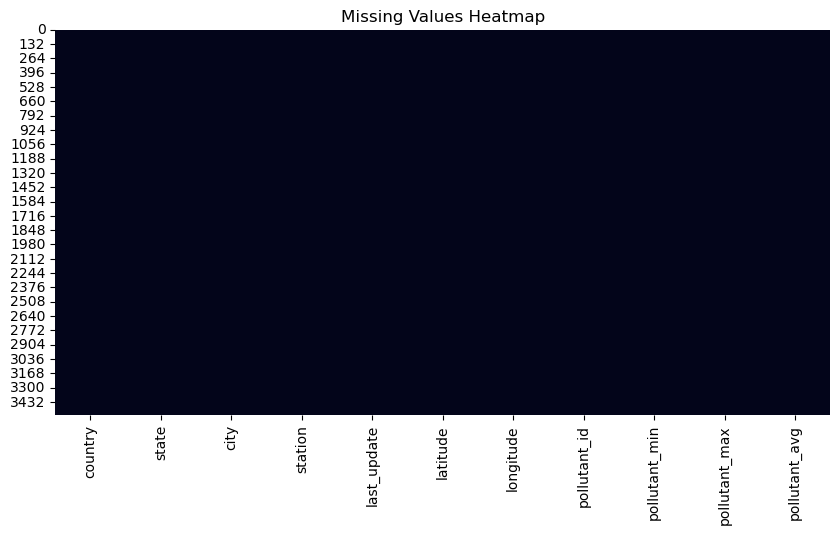

In [22]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [24]:
df.nunique()

country            1
state             31
city             270
station          507
last_update        1
latitude         507
longitude        507
pollutant_id       7
pollutant_min    108
pollutant_max    254
pollutant_avg    147
dtype: int64

In [25]:
df['pollutant_id'].unique()

array(['NO2', 'PM10', 'NH3', 'SO2', 'CO', 'PM2.5', 'OZONE'], dtype=object)

In [26]:
df['state'].value_counts()

state
Maharashtra          616
Uttar Pradesh        448
Rajasthan            322
Delhi                308
Haryana              210
Bihar                203
Madhya Pradesh       168
Karnataka            168
West Bengal          154
Gujarat              147
Andhra Pradesh       126
Odisha               119
Telangana             98
Chhattisgarh          91
Tamil Nadu            84
Assam                 63
Punjab                49
Kerala                35
Jammu and Kashmir     21
Chandigarh            21
Uttarakhand           14
Jharkhand             14
Meghalaya             14
Puducherry             7
Mizoram                7
Arunachal Pradesh      7
Ladakh                 7
Sikkim                 7
Himachal Pradesh       7
Nagaland               7
Tripura                7
Name: count, dtype: int64

In [27]:
df['city'].value_counts()

city
Delhi         308
Mumbai        161
Hyderabad      98
Bengaluru      63
Ahmedabad      56
             ... 
Davanagere      7
Gadag           7
Hubballi        7
Kalaburagi      7
Rajsamand       7
Name: count, Length: 270, dtype: int64

In [28]:
df['pollutant_id'].value_counts()

pollutant_id
NO2      507
PM10     507
NH3      507
SO2      507
CO       507
PM2.5    507
OZONE    507
Name: count, dtype: int64

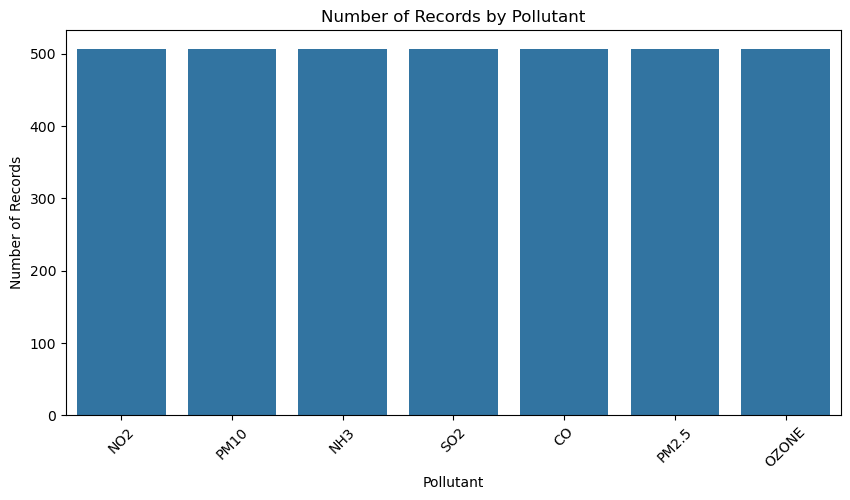

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='pollutant_id',
    order=df['pollutant_id'].value_counts().index
)

plt.title("Number of Records by Pollutant")
plt.xlabel("Pollutant")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [30]:
df.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3549.000000,3549.000000,3549.000000,3549.000000,3549.000000
mean,23.299252,78.519106,16.524655,42.880811,26.825585
std,5.163059,4.848291,18.244203,56.261661,27.817021
min,8.514909,70.776774,0.000000,0.000000,0.000000
25%,19.197090,75.386577,3.000000,8.000000,6.000000
50%,23.805690,77.296291,11.000000,26.000000,19.000000
75%,28.148556,80.518167,24.000000,56.000000,38.000000
max,34.147096,94.636574,187.000000,500.000000,188.000000


In [31]:
pollutant_cols = [
    'pollutant_min',
    'pollutant_max',
    'pollutant_avg'
]

df[pollutant_cols].describe()

,pollutant_min,pollutant_max,pollutant_avg
count,3549.000000,3549.000000,3549.000000
mean,16.524655,42.880811,26.825585
std,18.244203,56.261661,27.817021
min,0.000000,0.000000,0.000000
25%,3.000000,8.000000,6.000000
50%,11.000000,26.000000,19.000000
75%,24.000000,56.000000,38.000000
max,187.000000,500.000000,188.000000


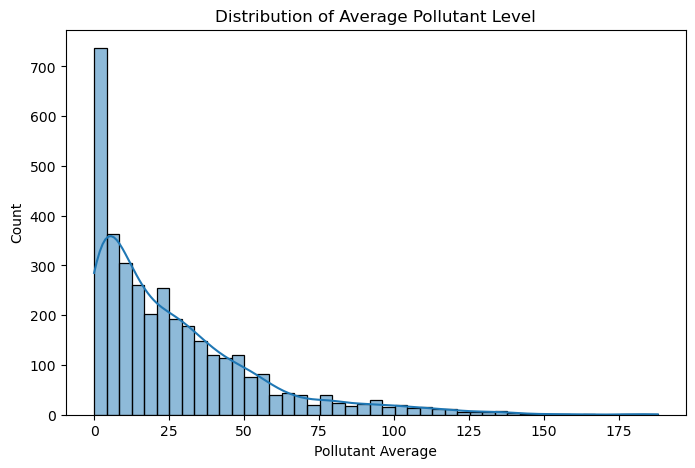

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['pollutant_avg'].dropna(),
    kde=True
)

plt.title("Distribution of Average Pollutant Level")
plt.xlabel("Pollutant Average")
plt.show()


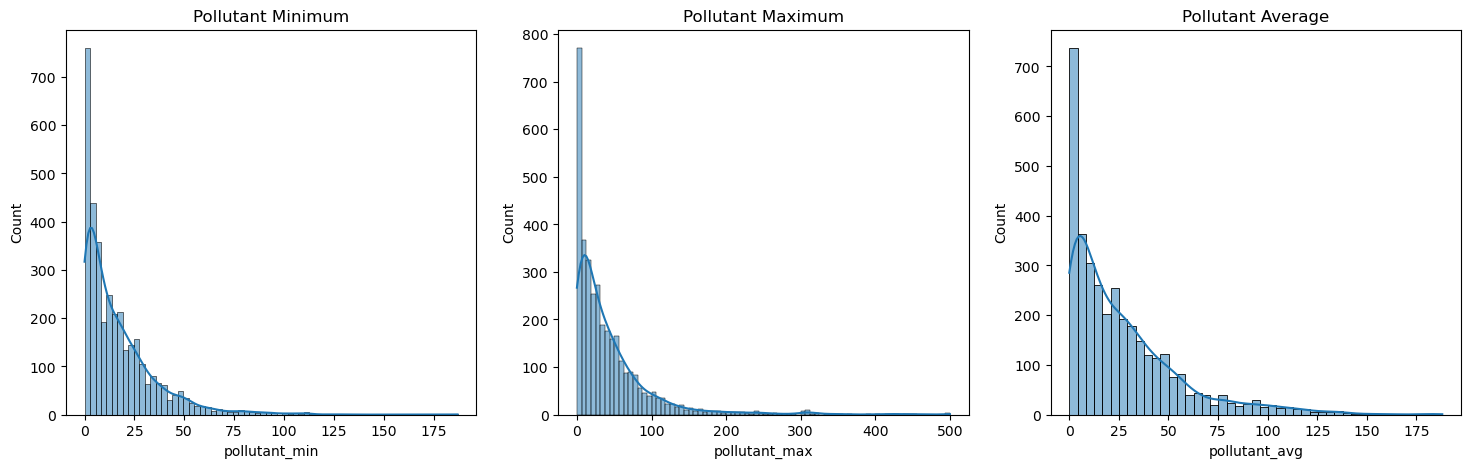

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['pollutant_min'].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Pollutant Minimum")

sns.histplot(df['pollutant_max'].dropna(), kde=True, ax=axes[1])
axes[1].set_title("Pollutant Maximum")

sns.histplot(df['pollutant_avg'].dropna(), kde=True, ax=axes[2])
axes[2].set_title("Pollutant Average")

plt.show()

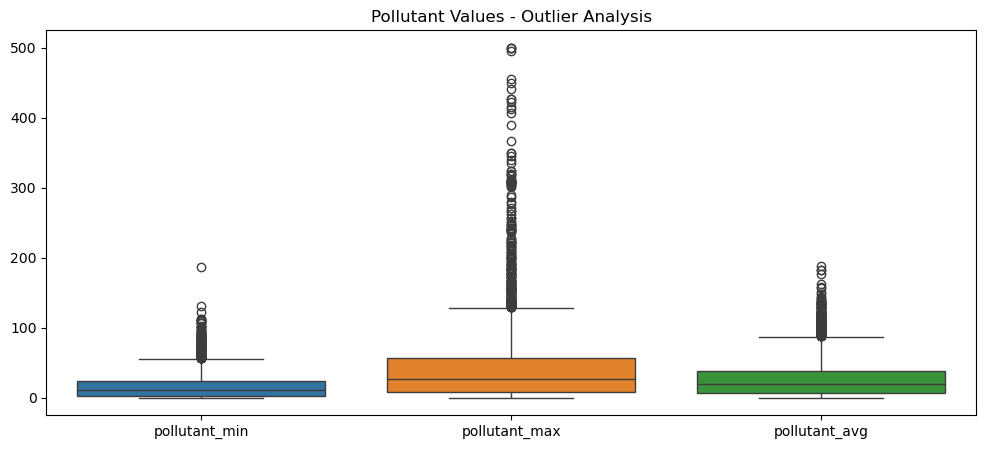

In [34]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df[pollutant_cols]
)

plt.title("Pollutant Values - Outlier Analysis")
plt.show()

In [35]:
for col in pollutant_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, "Outliers:", len(outliers))

pollutant_min Outliers: 140
pollutant_max Outliers: 206
pollutant_avg Outliers: 175


In [36]:
for col in pollutant_cols:
    print(col, "Zeros:", (df[col] == 0).sum())

pollutant_min Zeros: 427
pollutant_max Zeros: 344
pollutant_avg Zeros: 353


In [37]:
for col in pollutant_cols:
    print(
        col,
        "Negative values:",
        (df[col] < 0).sum()
    )

pollutant_min Negative values: 0
pollutant_max Negative values: 0
pollutant_avg Negative values: 0


In [38]:
df['last_update'] = pd.to_datetime(
    df['last_update'],
    format='%d-%m-%Y %H.%M',
    errors='coerce'
)

In [39]:
df['last_update'].dtype

dtype('<M8[ns]')

In [40]:
df[['latitude', 'longitude']].describe()

,latitude,longitude
count,3549.000000,3549.000000
mean,23.299252,78.519106
std,5.163059,4.848291
min,8.514909,70.776774
25%,19.197090,75.386577
50%,23.805690,77.296291
75%,28.148556,80.518167
max,34.147096,94.636574


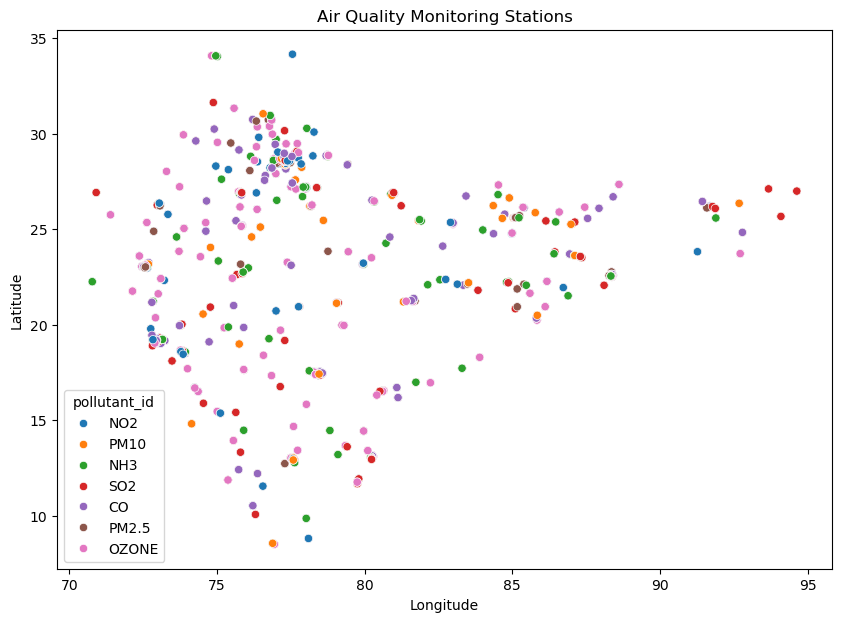

In [41]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='pollutant_id'
)

plt.title("Air Quality Monitoring Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [42]:
state_pollution = df.groupby('state')['pollutant_avg'].mean().sort_values(
    ascending=False
)

print(state_pollution)

state
Ladakh               57.000000
Himachal Pradesh     51.285714
Delhi                46.461039
Haryana              38.471429
Punjab               36.673469
Gujarat              32.115646
Rajasthan            29.472050
Uttar Pradesh        29.232143
Andhra Pradesh       29.055556
Bihar                26.738916
Madhya Pradesh       26.494048
Chandigarh           24.000000
Tripura              23.285714
West Bengal          22.396104
Kerala               21.228571
Assam                21.142857
Maharashtra          19.753247
Telangana            19.459184
Tamil Nadu           18.333333
Karnataka            18.113095
Odisha               17.344538
Puducherry           16.857143
Jammu and Kashmir    16.666667
Jharkhand            15.928571
Arunachal Pradesh    14.571429
Uttarakhand          14.214286
Chhattisgarh         13.879121
Nagaland             11.857143
Meghalaya             7.500000
Mizoram               5.571429
Sikkim                2.571429
Name: pollutant_avg, dtype: float

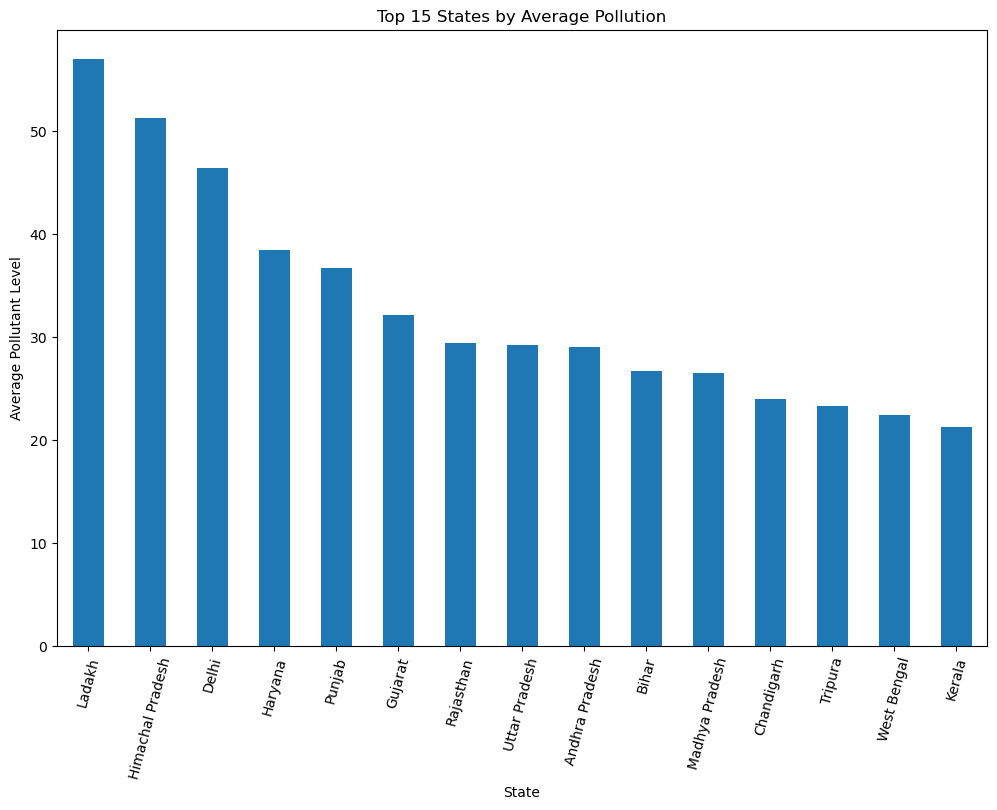

In [43]:
plt.figure(figsize=(12,8))

state_pollution.head(15).plot(kind='bar')

plt.title("Top 15 States by Average Pollution")
plt.xlabel("State")
plt.ylabel("Average Pollutant Level")
plt.xticks(rotation=75)
plt.show()

In [44]:
pollutant_analysis = df.groupby('pollutant_id')[
    ['pollutant_min', 'pollutant_max', 'pollutant_avg']
].mean()

print(pollutant_analysis)

              pollutant_min  pollutant_max  pollutant_avg
pollutant_id                                             
CO                24.457594      39.570020      31.260355
NH3                2.972387       5.641026       3.982249
NO2               12.457594      29.755424      18.992110
OZONE             16.940828      35.374753      25.546351
PM10              31.343195      89.903353      54.443787
PM2.5             19.321499      83.128205      41.950690
SO2                8.179487      16.792899      11.603550


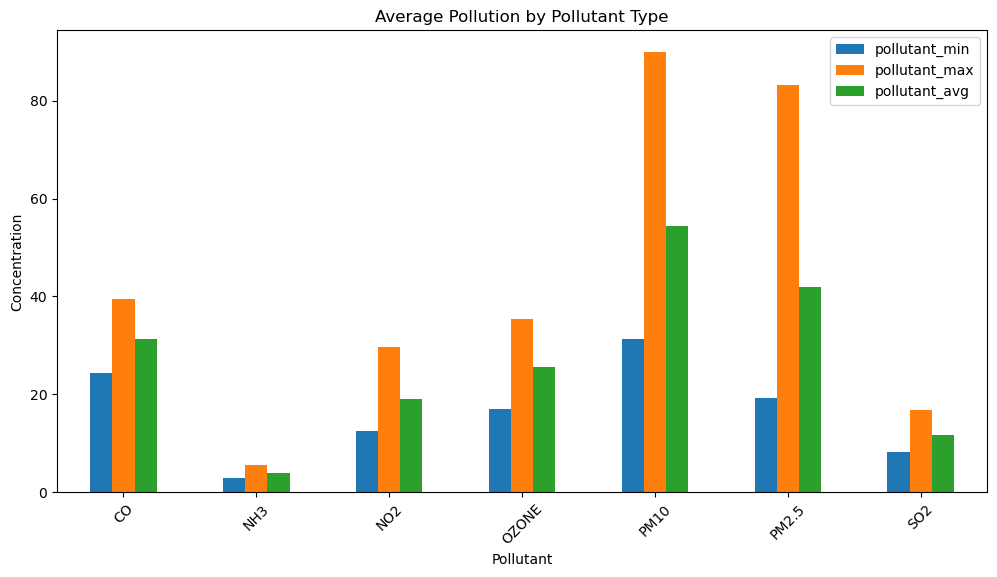

In [45]:
pollutant_analysis.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Pollution by Pollutant Type")
plt.xlabel("Pollutant")
plt.ylabel("Concentration")
plt.xticks(rotation=45)
plt.show()

In [46]:
invalid = df[
    (df['pollutant_min'] > df['pollutant_avg']) |
    (df['pollutant_avg'] > df['pollutant_max'])
]

print("Invalid records:", len(invalid))

Invalid records: 0


In [47]:
invalid_lat = df[
    (df['latitude'] < -90) |
    (df['latitude'] > 90)
]

invalid_lon = df[
    (df['longitude'] < -180) |
    (df['longitude'] > 180)
]

print("Invalid latitude:", len(invalid_lat))
print("Invalid longitude:", len(invalid_lon))

Invalid latitude: 0
Invalid longitude: 0


In [48]:
df['country'].unique()

array(['India'], dtype=object)

In [49]:
df['state'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Arunachal Pradesh',
       'Chandigarh', 'Chhattisgarh', 'Delhi', 'Haryana', 'Gujarat',
       'Kerala', 'Ladakh', 'Madhya Pradesh', 'Himachal Pradesh',
       'Jammu and Kashmir', 'Jharkhand', 'Maharashtra', 'Karnataka',
       'Meghalaya', 'Nagaland', 'Odisha', 'Tamil Nadu', 'Telangana',
       'Rajasthan', 'Punjab', 'Sikkim', 'Uttar Pradesh', 'Uttarakhand',
       'West Bengal', 'Mizoram', 'Puducherry', 'Tripura'], dtype=object)

In [50]:
df['pollutant_id'].unique()

array(['NO2', 'PM10', 'NH3', 'SO2', 'CO', 'PM2.5', 'OZONE'], dtype=object)

In [51]:
Univariate Analysis 
- Univariate analysis = analyzing one variable at a time.

SyntaxError: invalid syntax (328732869.py, line 1)

CSV files found:
Air Quality Prediction.csv
Mobile_Repair_Shop_Synthetic_Dataset_20000.csv
Mobile_Repair_Shop_Synthetic_Dataset_20000_Updated(1).csv

Dataset loaded successfully!
File: Air Quality Prediction.csv
Shape: (3549, 11)


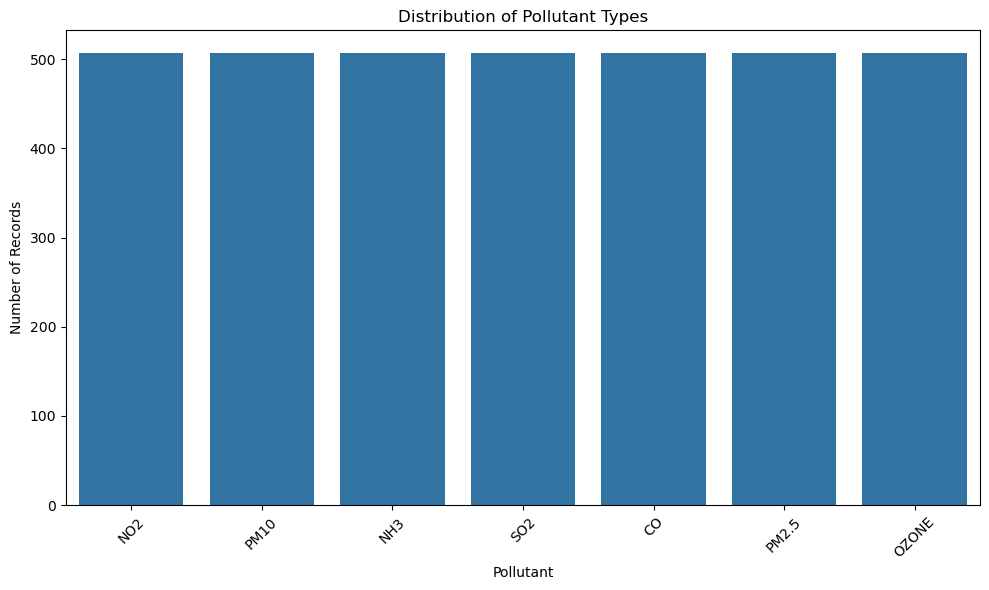

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob 

csv_files = glob.glob("*.csv")

print("CSV files found:")
for file in csv_files:
    print(file)
air_quality_files = [
    file for file in csv_files
    if "Air Quality Prediction" in file
]

if len(air_quality_files) == 0:
    print("\nERROR: Air Quality CSV file was not found.")
else:
    file_path = air_quality_files[0]

   
    df = pd.read_csv(file_path)

    print("\nDataset loaded successfully!")
    print("File:", file_path)
    print("Shape:", df.shape)

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x='pollutant_id'
    )

    plt.title("Distribution of Pollutant Types")
    plt.xlabel("Pollutant")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

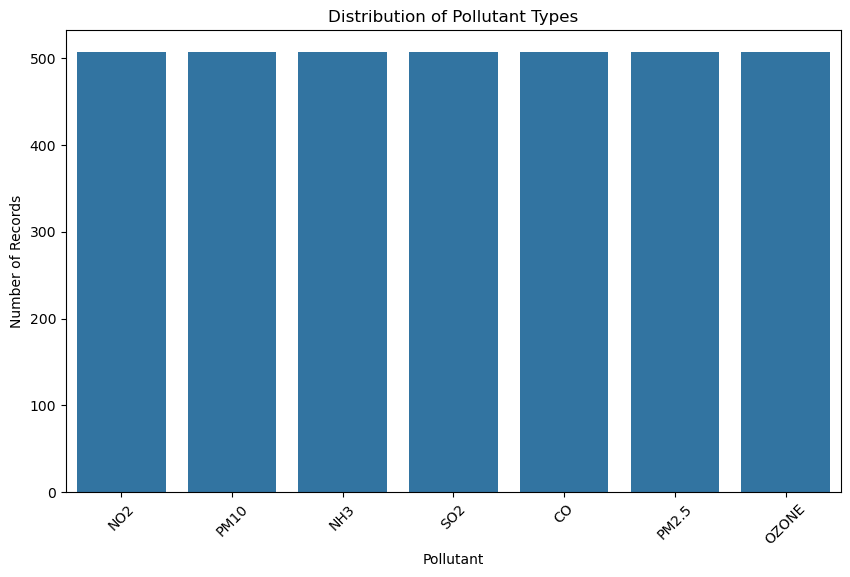

In [53]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='pollutant_id'
)

plt.title("Distribution of Pollutant Types")
plt.xlabel("Pollutant")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()

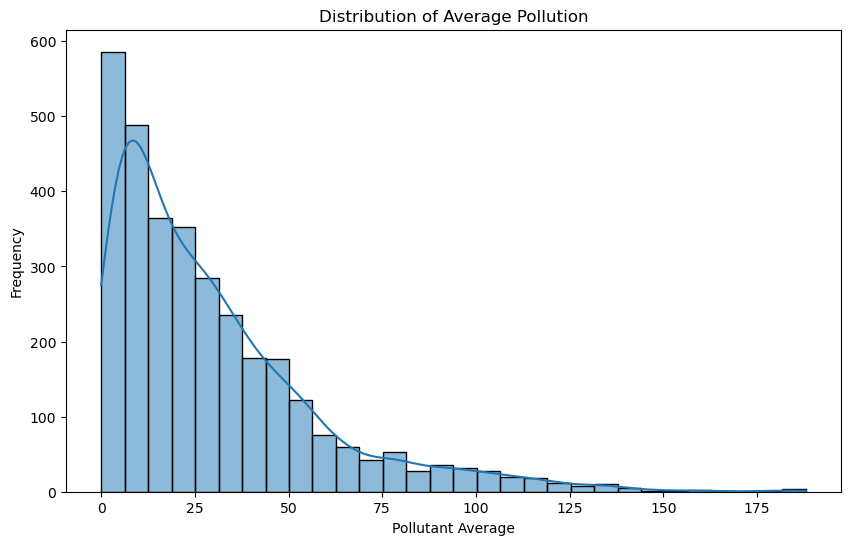

In [54]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['pollutant_avg'].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Average Pollution")
plt.xlabel("Pollutant Average")
plt.ylabel("Frequency")

plt.show()

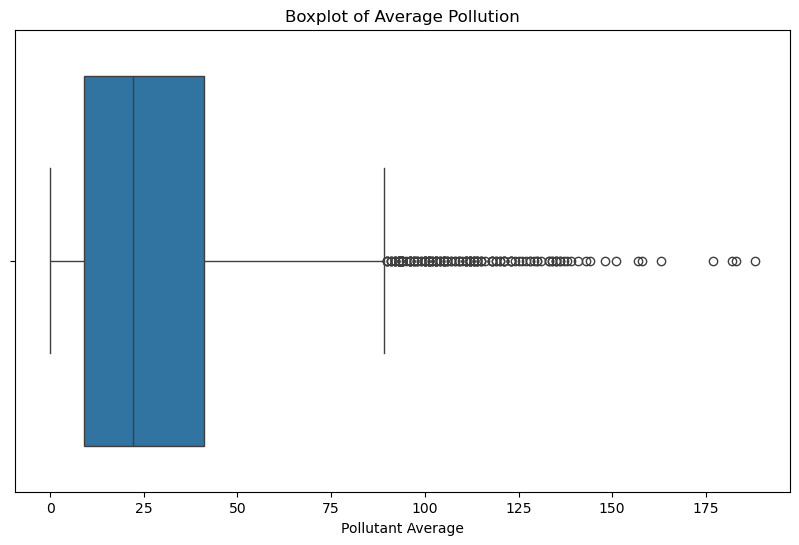

In [55]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df['pollutant_avg']
)

plt.title("Boxplot of Average Pollution")
plt.xlabel("Pollutant Average")

plt.show()

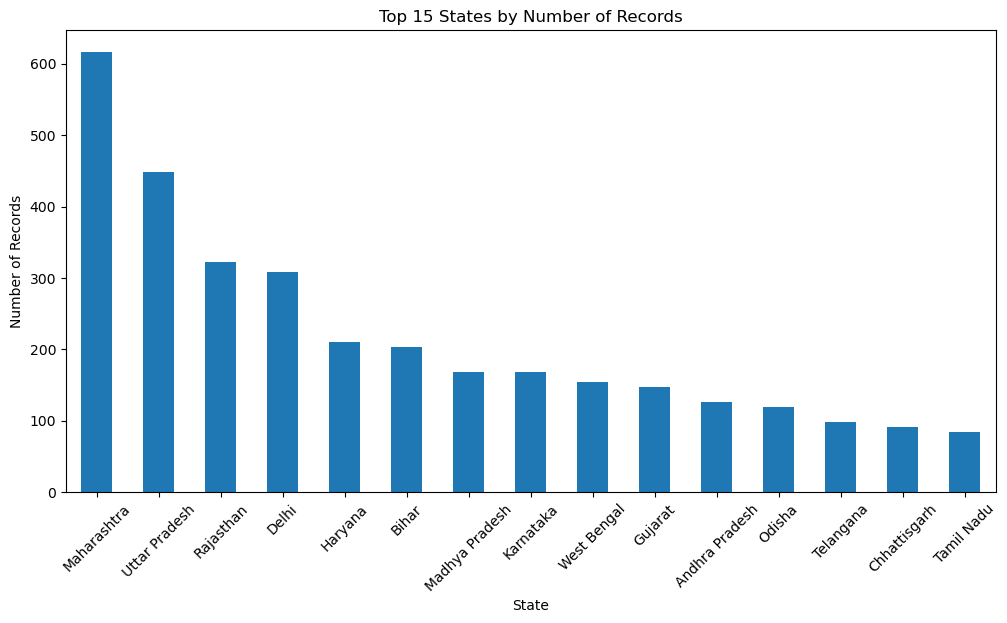

In [56]:
plt.figure(figsize=(12, 6))

df['state'].value_counts().head(15).plot(
    kind='bar'
)

plt.title("Top 15 States by Number of Records")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()

In [57]:
Bivariate Analysis
-Bivariate analysis = relationship between two variables.

SyntaxError: invalid syntax (4035222087.py, line 1)

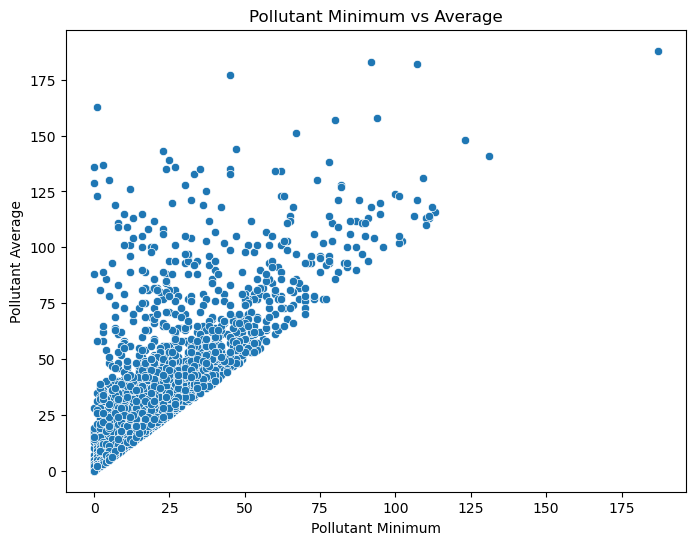

In [58]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='pollutant_min',
    y='pollutant_avg'
)

plt.title("Pollutant Minimum vs Average")
plt.xlabel("Pollutant Minimum")
plt.ylabel("Pollutant Average")

plt.show()

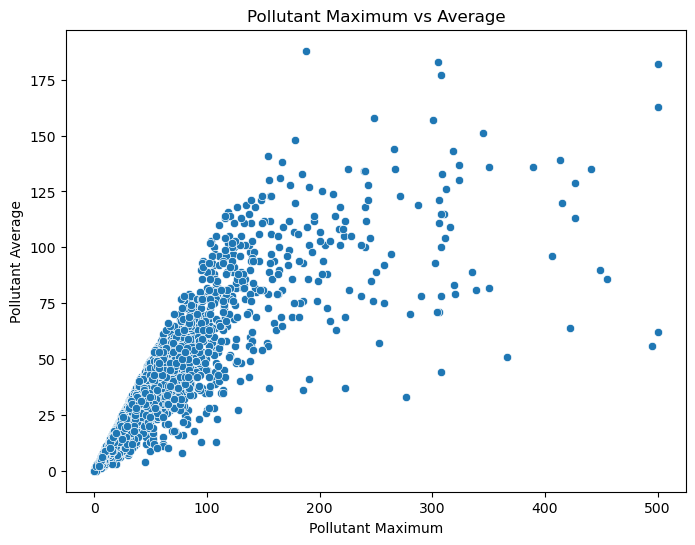

In [59]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='pollutant_max',
    y='pollutant_avg'
)

plt.title("Pollutant Maximum vs Average")
plt.xlabel("Pollutant Maximum")
plt.ylabel("Pollutant Average")

plt.show()

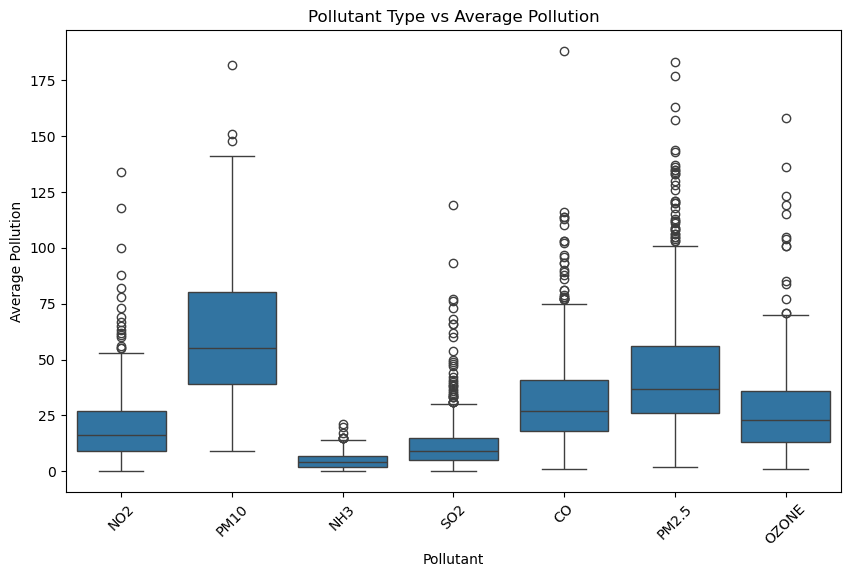

In [60]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='pollutant_id',
    y='pollutant_avg'
)

plt.title("Pollutant Type vs Average Pollution")
plt.xlabel("Pollutant")
plt.ylabel("Average Pollution")
plt.xticks(rotation=45)

plt.show()

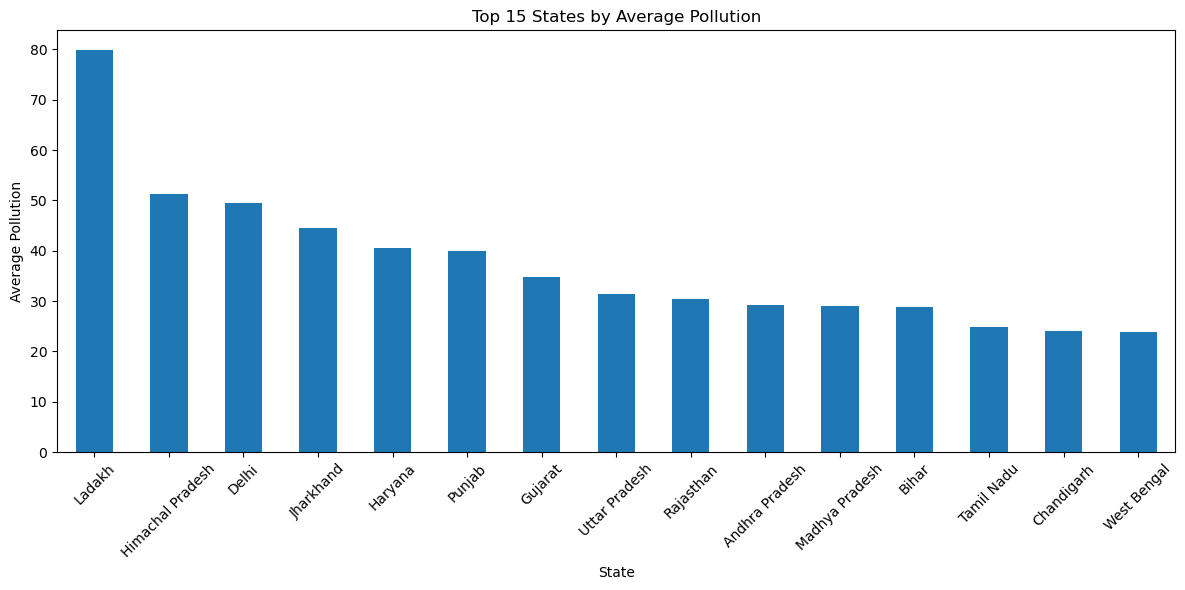

In [61]:
state_avg = (
    df.groupby('state')['pollutant_avg']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

state_avg.plot(kind='bar')

plt.title("Top 15 States by Average Pollution")
plt.xlabel("State")
plt.ylabel("Average Pollution")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
numeric_columns = [
    'latitude',
    'longitude',
    'pollutant_min',
    'pollutant_max',
    'pollutant_avg'
]

correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
latitude,1.000000,0.093429,0.100603,0.204332,0.206602
longitude,0.093429,1.000000,-0.053362,-0.049518,-0.075212
pollutant_min,0.100603,-0.053362,1.000000,0.478013,0.800550
pollutant_max,0.204332,-0.049518,0.478013,1.000000,0.852145
pollutant_avg,0.206602,-0.075212,0.800550,0.852145,1.000000


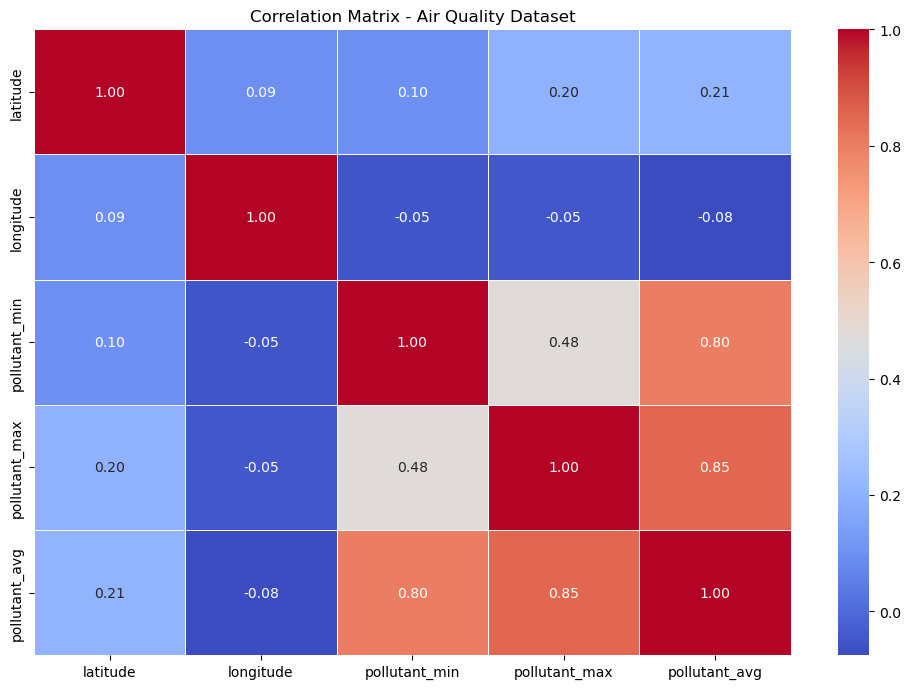

In [64]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix - Air Quality Dataset")

plt.tight_layout()
plt.show()

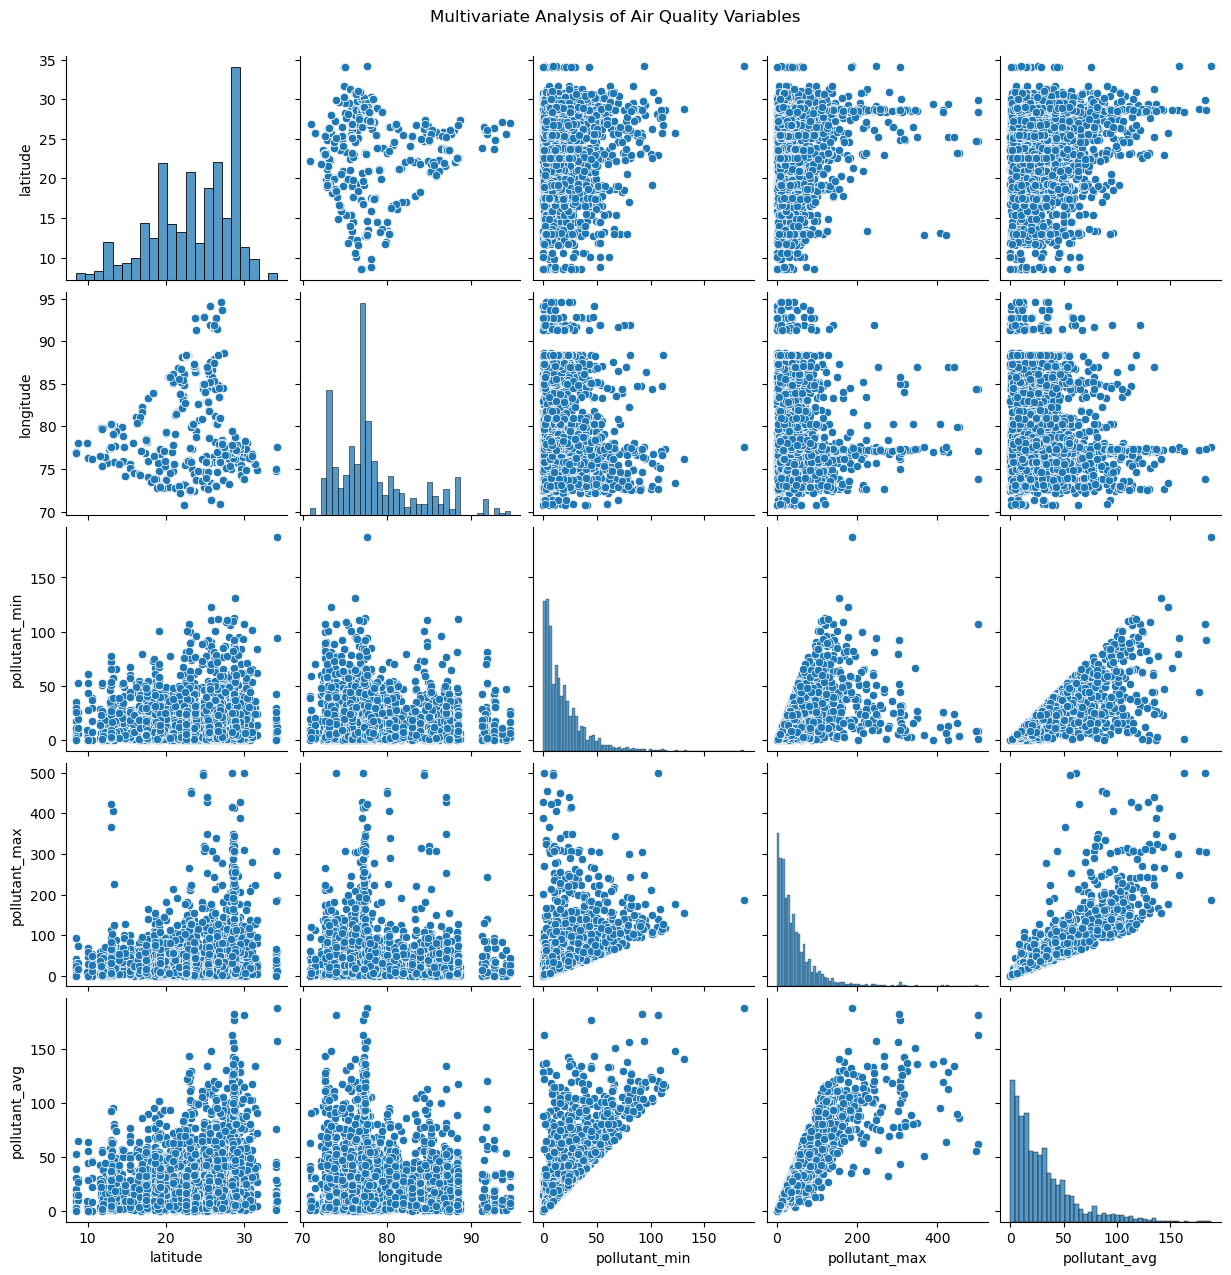

In [65]:
pairplot_data = df[
    [
        'latitude',
        'longitude',
        'pollutant_min',
        'pollutant_max',
        'pollutant_avg'
    ]
].dropna()

sns.pairplot(pairplot_data)

plt.suptitle(
    "Multivariate Analysis of Air Quality Variables",
    y=1.02
)

plt.show()

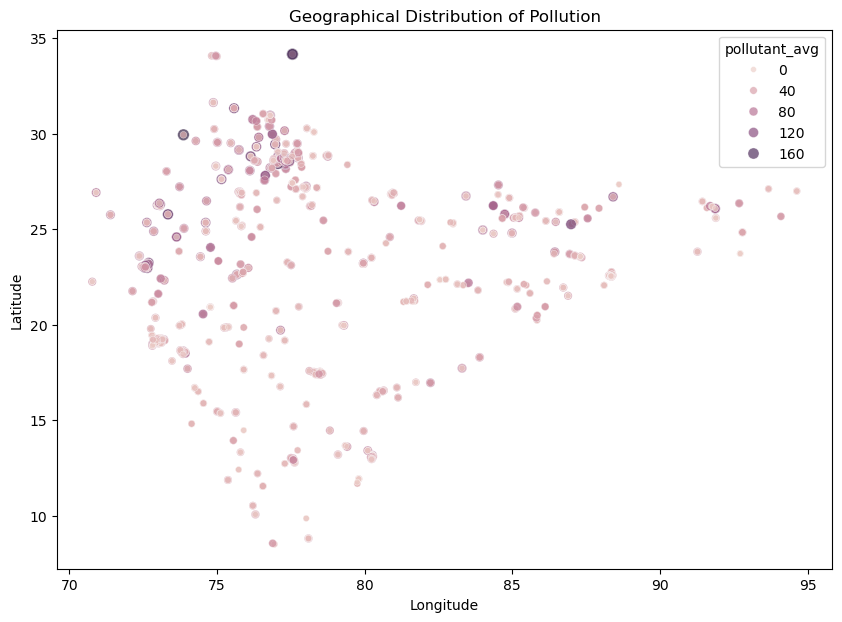

In [66]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='pollutant_avg',
    size='pollutant_avg',
    alpha=0.7
)

plt.title("Geographical Distribution of Pollution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [1]:
EDA Insights:
    
-PM10 has the highest average recorded pollutant value.
-Pollutant maximum and average have a strong positive correlation (0.85).
-Pollutant minimum and average also show a strong correlation (0.80).
-Latitude has a weak-to-moderate relationship with average pollution, while longitude has very little linear relationship.
-The dataset covers 31 states, 270 cities, 507 stations, and 7 pollutant types.

SyntaxError: invalid syntax (714485583.py, line 1)